In [54]:
# ============================================================
# Climate Smart Agriculture using Temporal Fusion Transformer
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from pytorch_forecasting import (
    TimeSeriesDataSet,
    TemporalFusionTransformer
)

from pytorch_forecasting.data import GroupNormalizer

from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping

In [55]:
df = pd.read_excel("../data/raw/chad_csa_dataset_complete_42_variables.xlsx")

In [56]:
print(df.dtypes[[
    "Region",
    "ClimateZone",
    "CropType",
    "CropVariety",
    "SoilTexture",
    "LandUse"
]])

print(df[[
    "Region",
    "ClimateZone",
    "CropType"
]].head())

Region         object
ClimateZone    object
CropType       object
CropVariety    object
SoilTexture    object
LandUse        object
dtype: object
      Region ClimateZone CropType
0  N'Djamena       Sahel   Millet
1     Abéché       Sahel  Sorghum
2        Ati       Sahel   Millet
3      Mongo       Sahel  Sorghum
4     Bongor    Sudanian    Maize


In [57]:
# Sort the dataset
df = df.sort_values(["Region", "CropType", "Year", "Month"]).reset_index(drop=True)

# Create sequential time index
df["time_idx"] = (
    (df["Year"] - df["Year"].min()) * 12
    + (df["Month"] - 1)
)

print(df[["Year", "Month", "time_idx"]].head())

   Year  Month  time_idx
0  2000      8         7
1  2000     10         9
2  2001      2        13
3  2003      7        42
4  2003     10        45


In [58]:
df["group"] = (
    df["Region"].astype(str)
    + "_"
    + df["CropType"].astype(str)
)

print(df["group"].head())

0    Abéché_Maize
1    Abéché_Maize
2    Abéché_Maize
3    Abéché_Maize
4    Abéché_Maize
Name: group, dtype: object


In [59]:
group_sizes = df.groupby("group").size()

print(group_sizes.describe())

print(group_sizes.sort_values().head(20))

count     32.000000
mean      75.000000
std       24.649805
min       36.000000
25%       52.500000
50%       75.000000
75%       99.750000
max      109.000000
dtype: float64
group
Ati_Sesame           36
Bongor_Sesame        41
Moundou_Maize        44
N'Djamena_Sesame     45
Sarh_Sesame          45
Sarh_Maize           46
Mongo_Sesame         50
Pala_Maize           51
Moundou_Sesame       53
Abéché_Sesame        54
Pala_Sesame          57
Abéché_Maize         59
Ati_Maize            63
N'Djamena_Maize      64
Mongo_Maize          65
Bongor_Maize         71
Bongor_Sorghum       79
Mongo_Sorghum        82
Abéché_Sorghum       82
N'Djamena_Sorghum    83
dtype: int64


In [62]:
max_encoder_length = 18
max_prediction_length = 6

In [63]:
group_sizes = df.groupby("group").size()

print(group_sizes.describe())

print(group_sizes.sort_values().head(20))

count     32.000000
mean      75.000000
std       24.649805
min       36.000000
25%       52.500000
50%       75.000000
75%       99.750000
max      109.000000
dtype: float64
group
Ati_Sesame           36
Bongor_Sesame        41
Moundou_Maize        44
N'Djamena_Sesame     45
Sarh_Sesame          45
Sarh_Maize           46
Mongo_Sesame         50
Pala_Maize           51
Moundou_Sesame       53
Abéché_Sesame        54
Pala_Sesame          57
Abéché_Maize         59
Ati_Maize            63
N'Djamena_Maize      64
Mongo_Maize          65
Bongor_Maize         71
Bongor_Sorghum       79
Mongo_Sorghum        82
Abéché_Sorghum       82
N'Djamena_Sorghum    83
dtype: int64


In [ ]:

training_cutoff = df["time_idx"].max() - max_prediction_length

print("Training cutoff:", training_cutoff)

Training cutoff: 293


In [66]:
allow_missing_timesteps=True

In [68]:
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer

# ==========================================
# Create Training Dataset
# ==========================================

training = TimeSeriesDataSet(

    df[df.time_idx <= training_cutoff],

    time_idx="time_idx",

    target="CropYield_t_ha",

    group_ids=["group"],

    max_encoder_length=max_encoder_length,

    max_prediction_length=max_prediction_length,

    static_categoricals=[
        "Region",
        "ClimateZone",
        "CropType",
        "CropVariety",
        "SoilTexture",
        "LandUse"
    ],

    static_reals=[
        "Elevation_m"
    ],

    time_varying_known_reals=[
        "time_idx",
        "Year",
        "Month",
        "SowingMonth",
        "HarvestMonth",
        "GrowingSeason_days"
    ],

    time_varying_unknown_reals=[
        "Rainfall_mm",
        "MaxTemp_C",
        "MinTemp_C",
        "AvgTemp_C",
        "RelativeHumidity_%",
        "WindSpeed_mps",
        "SolarRadiation_MJ",
        "Evapotranspiration_mm",
        "SPI",
        "SPEI",
        "NDVI",
        "EVI",
        "LandSurfaceTemp_C",
        "SoilMoisture_%",
        "SoilTemperature_C",
        "SoilOrganicCarbon_%",
        "SoilPH",
        "SoilNitrogen_%",
        "SoilPhosphorus_mgkg",
        "SoilPotassium_mgkg",
        "BulkDensity_gcm3",
        "HarvestedArea_ha",
        "Irrigation_%",
        "Fertilizer_kg_ha",
        "FarmSize_ha",
        "PopulationDensity_km2",
        "DrySpell_days"
    ],

    target_normalizer=GroupNormalizer(
        groups=["group"]
    ),

    add_relative_time_idx=True,

    add_target_scales=True,

    add_encoder_length=True,

    allow_missing_timesteps=True
)

In [69]:
validation = TimeSeriesDataSet.from_dataset(
    training,
    df,
    predict=True,
    stop_randomization=True
)

In [70]:
batch_size = 64

train_dataloader = training.to_dataloader(
    train=True,
    batch_size=batch_size,
    num_workers=0
)

val_dataloader = validation.to_dataloader(
    train=False,
    batch_size=batch_size,
    num_workers=0
)

print("Training batches:", len(train_dataloader))
print("Validation batches:", len(val_dataloader))

Training batches: 9
Validation batches: 1


In [71]:
from lightning.pytorch.callbacks import EarlyStopping

early_stop_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=1e-4,
    patience=10,
    verbose=True,
    mode="min"
)

In [72]:
from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

tft = TemporalFusionTransformer.from_dataset(

    training,

    learning_rate=0.001,

    hidden_size=32,

    attention_head_size=4,

    dropout=0.1,

    hidden_continuous_size=16,

    output_size=7,

    loss=QuantileLoss(),

    log_interval=10,

    reduce_on_plateau_patience=4
)

print(f"Number of parameters: {tft.size()/1e3:.1f}k")

Number of parameters: 159.9k


In [73]:
from lightning.pytorch import Trainer

trainer = Trainer(

    max_epochs=50,

    accelerator="auto",

    devices=1,

    callbacks=[early_stop_callback],

    gradient_clip_val=0.1,

    enable_progress_bar=True
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [74]:
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     69 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  1.2 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  9.0 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 84.0 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 14.0 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  2.6 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 159 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 159 K                                                                                                
Total estimated model params size (MB): 0.639                                                                      
Modules in train mode: 859                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric val_loss improved. New best score: 0.259


...

Metric val_loss improved by 0.001 >= min_delta = 0.0001. New best score: 0.059


Metric val_loss improved by 0.000 >= min_delta = 0.0001. New best score: 0.059


Metric val_loss improved by 0.001 >= min_delta = 0.0001. New best score: 0.058


Metric val_loss improved by 0.004 >= min_delta = 0.0001. New best score: 0.054


Monitored metric val_loss did not improve in the last 10 records. Best score: 0.054. Signaling Trainer to stop.


In [75]:
trainer.save_checkpoint("tft_crop_yield_prediction.ckpt")

`weights_only` was not set, defaulting to `False`.


In [76]:
# ==========================================
# Generate Predictions
# ==========================================

predictions = tft.predict(
    val_dataloader,
    return_y=True
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


In [77]:
# Predicted values
y_pred = predictions.output.cpu().numpy().flatten()

# Actual values
y_true = predictions.y[0].cpu().numpy().flatten()

In [78]:
print("Predicted:", y_pred.shape)
print("Actual:", y_true.shape)

Predicted: (54,)
Actual: (54,)


In [79]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# MAE
mae = mean_absolute_error(y_true, y_pred)

# RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# R²
r2 = r2_score(y_true, y_pred)

# MAPE
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 0.1145
RMSE : 0.1382
R²   : 0.9624
MAPE : 5.53%


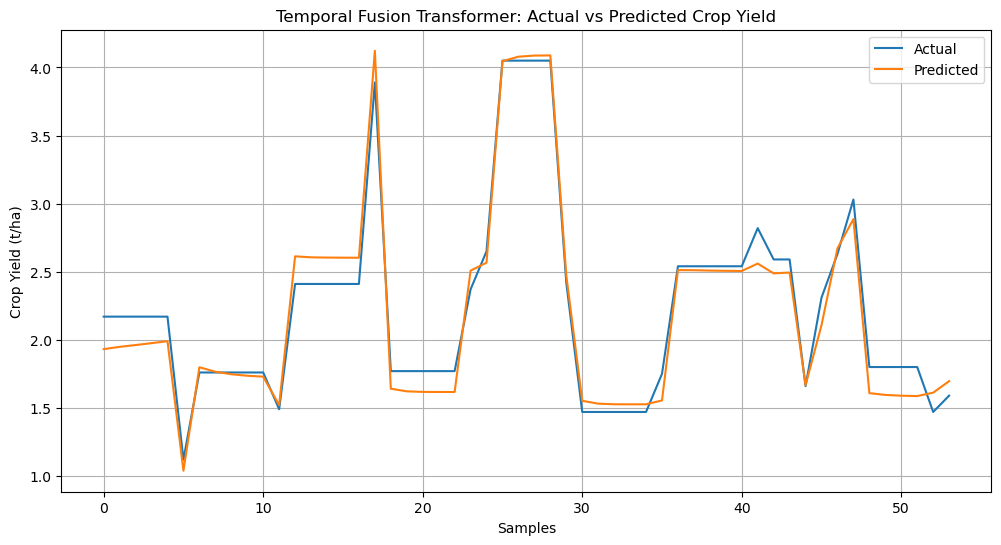

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_true[:100], label="Actual")

plt.plot(y_pred[:100], label="Predicted")

plt.xlabel("Samples")

plt.ylabel("Crop Yield (t/ha)")

plt.title("Temporal Fusion Transformer: Actual vs Predicted Crop Yield")

plt.legend()

plt.grid(True)

plt.show()

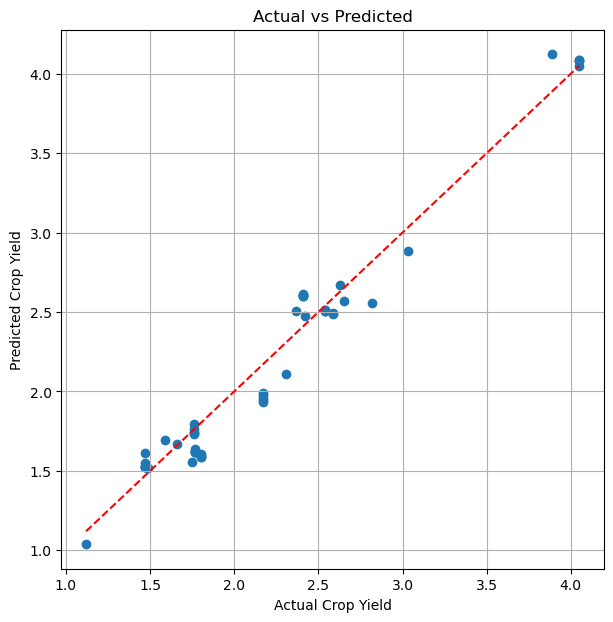

In [81]:
plt.figure(figsize=(7,7))

plt.scatter(y_true, y_pred)

plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    'r--'
)

plt.xlabel("Actual Crop Yield")

plt.ylabel("Predicted Crop Yield")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

In [82]:
results = pd.DataFrame({
    "Actual": y_true,
    "Predicted": y_pred
})

results.to_csv("tft_predictions.csv", index=False)

print(results.head())

   Actual  Predicted
0    2.17   1.931366
1    2.17   1.948329
2    2.17   1.961423
3    2.17   1.975367
4    2.17   1.989803


In [83]:
# Generate raw predictions for interpretation
raw_predictions = tft.predict(
    val_dataloader,
    mode="raw",
    return_x=True
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


In [ ]:
interpretation = tft.interpret_output(
    raw_predictions.output,
    reduction="sum"
)

{'attention': <Figure size 640x480 with 1 Axes>,
 'static_variables': <Figure size 700x450 with 1 Axes>,
 'encoder_variables': <Figure size 700x1050 with 1 Axes>,
 'decoder_variables': <Figure size 700x375 with 1 Axes>}

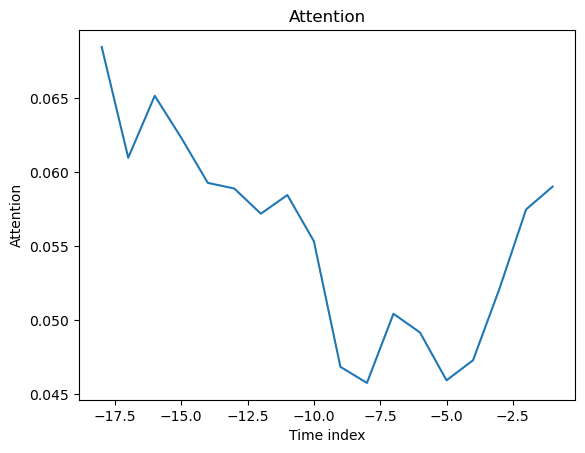

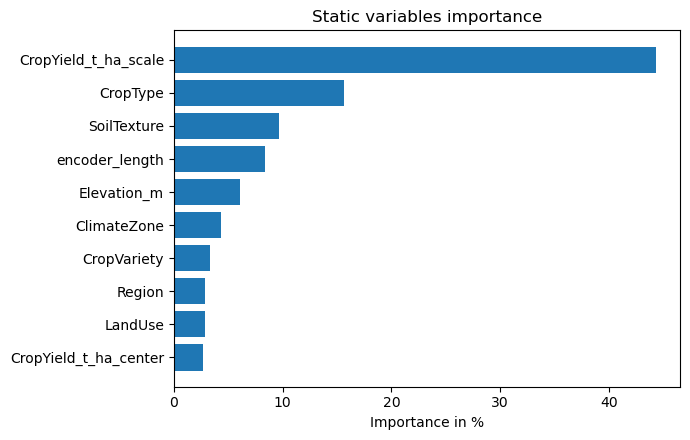

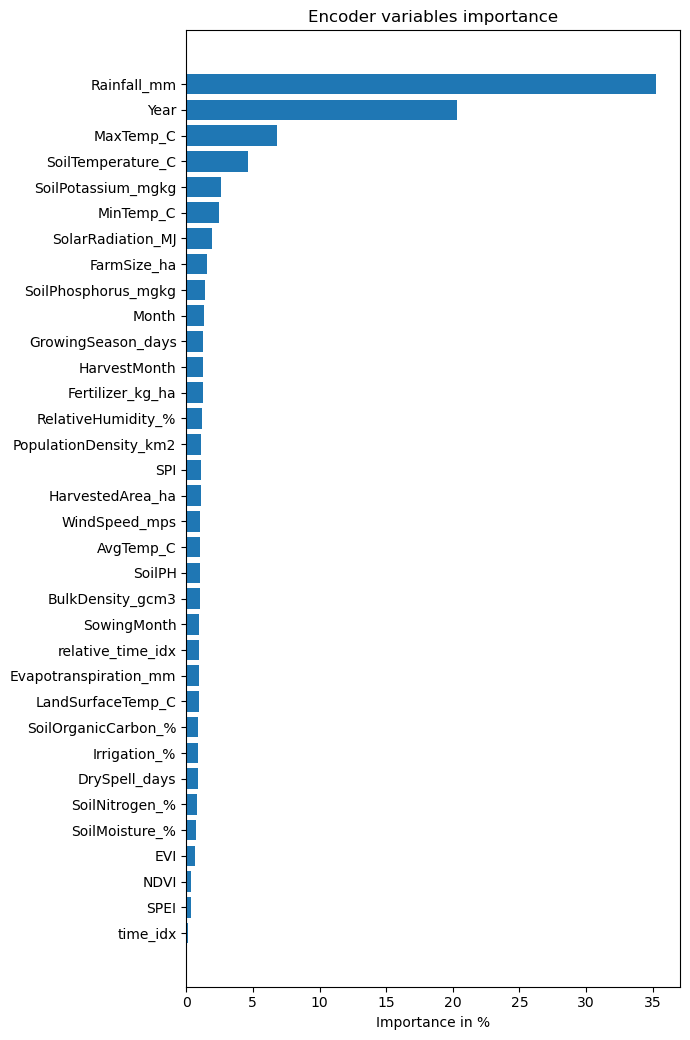

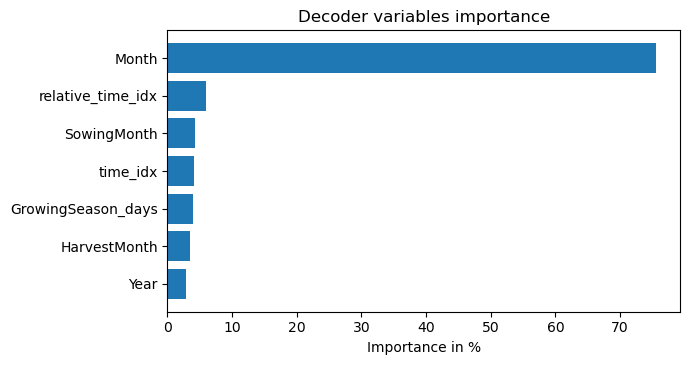

In [85]:
tft.plot_interpretation(interpretation)

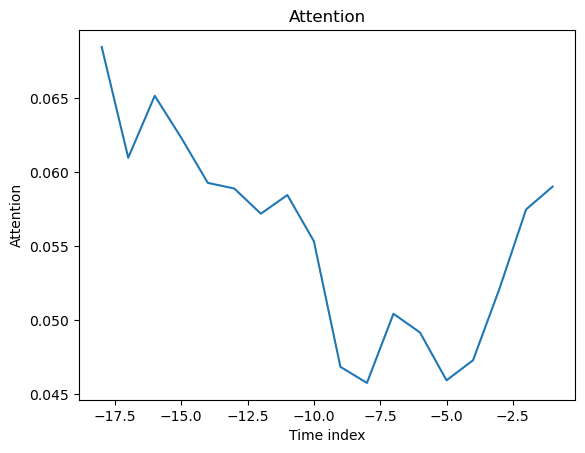

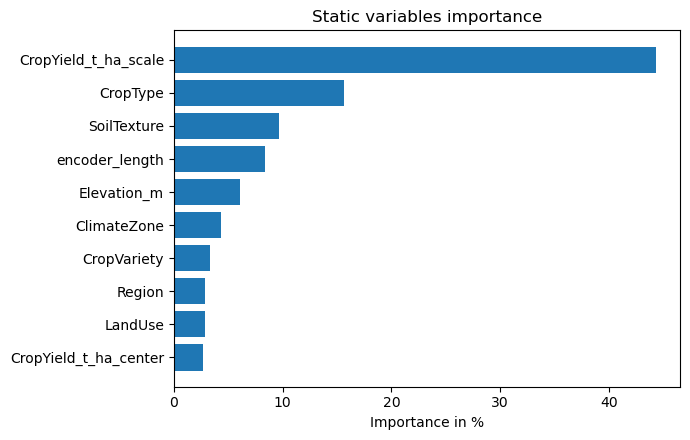

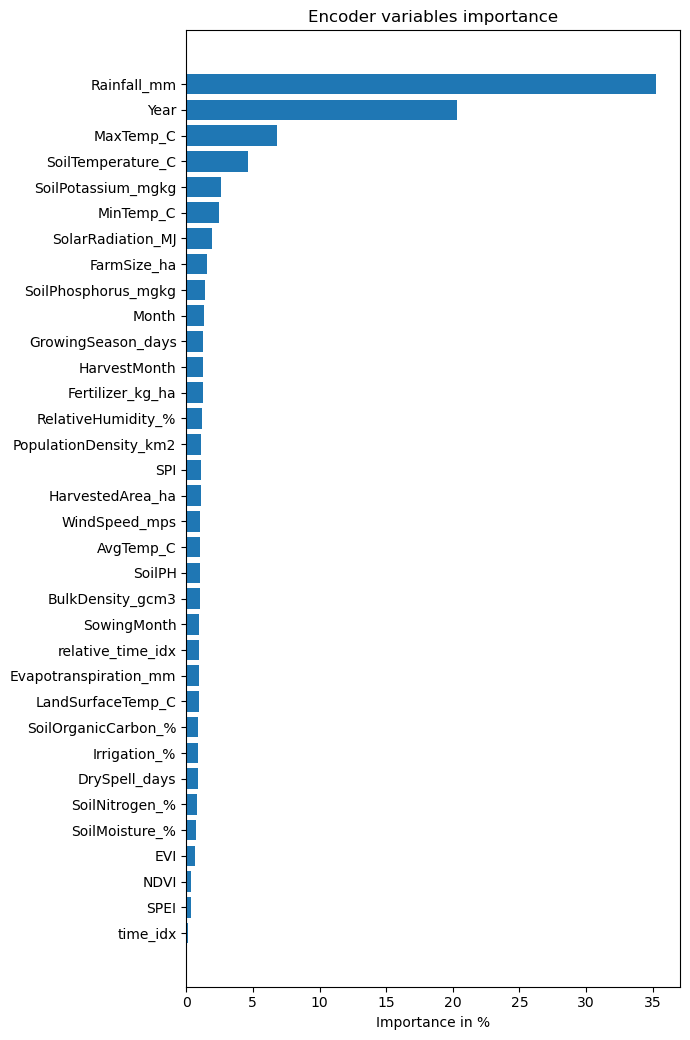

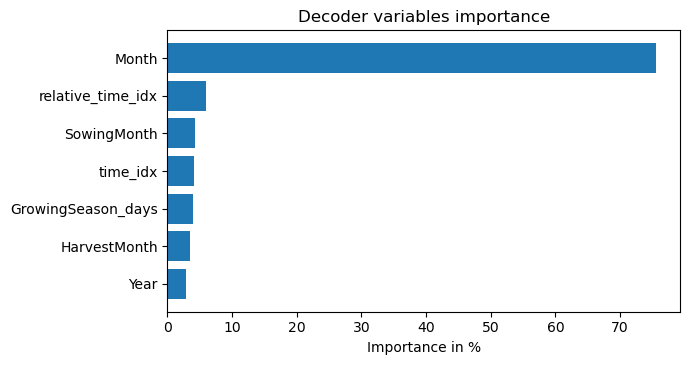

In [109]:
import matplotlib.pyplot as plt

tft.plot_interpretation(interpretation)
plt.show()

In [110]:
plt.savefig("tft_interpretation.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

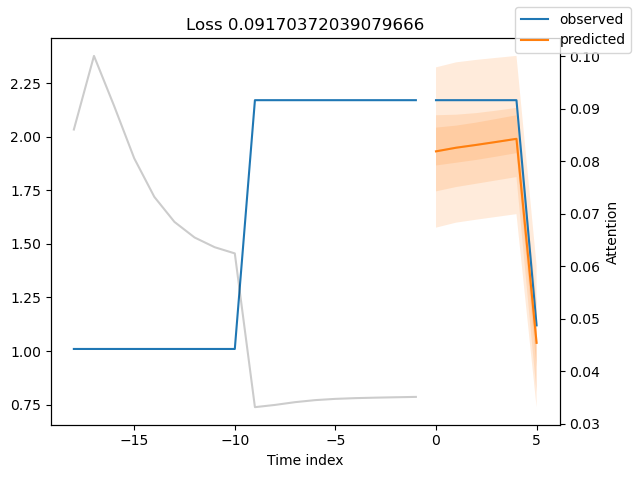

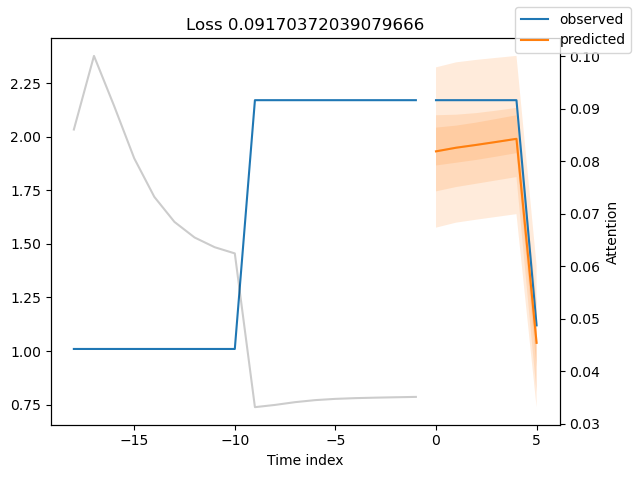

In [ ]:
tft.plot_prediction(
    raw_predictions.x,
    raw_predictions.output,
    idx=0,
    add_loss_to_title=True
)

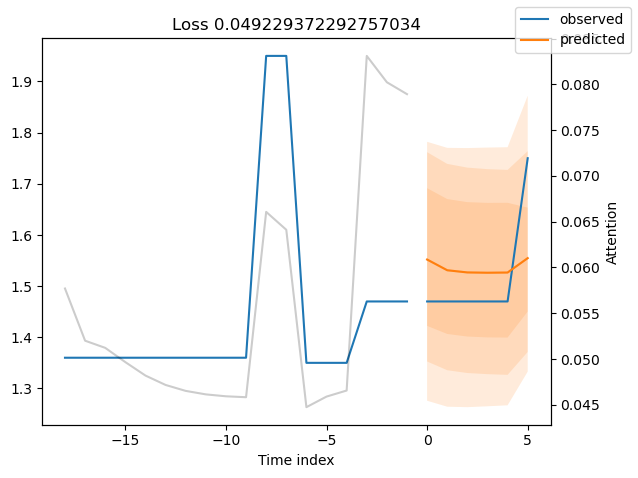

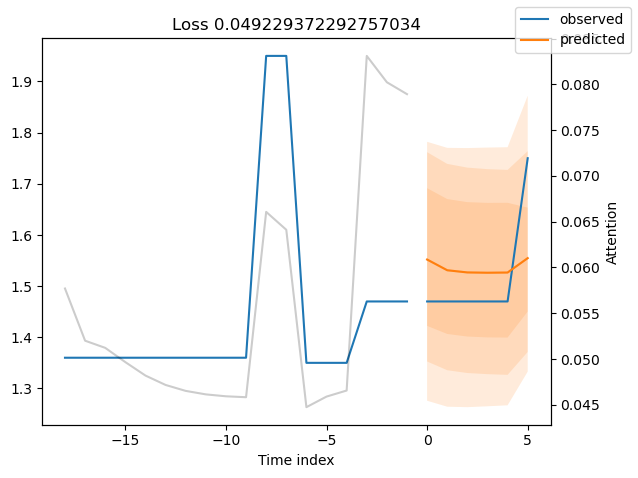

In [112]:
tft.plot_prediction(
    raw_predictions.x,
    raw_predictions.output,
    idx=5,
    add_loss_to_title=True
)

In [113]:
print(interpretation["encoder_variables"])

tensor([0.0094, 1.8265, 0.1198, 0.0878, 0.1140, 0.1148, 0.0856, 3.1750, 0.6100,
        0.2189, 0.0940, 0.1049, 0.0940, 0.1744, 0.0847, 0.0975, 0.0294, 0.0311,
        0.0591, 0.0830, 0.0642, 0.4138, 0.0825, 0.0926, 0.0699, 0.1277, 0.2369,
        0.0899, 0.0969, 0.0808, 0.1123, 0.1391, 0.1012, 0.0784],
       device='mps:0')


In [114]:
print(interpretation["decoder_variables"])

tensor([0.3688, 0.2571, 6.7940, 0.3776, 0.3131, 0.3534, 0.5360],
       device='mps:0')


In [115]:
print(interpretation["static_variables"])

tensor([0.2567, 0.3869, 1.4086, 0.2980, 0.8662, 0.2538, 0.5462, 0.7545, 0.2421,
        3.9871], device='mps:0')
